# PS-S06E07: CatBoost

This notebook tackles the [**Playground Series – Season 6, Episode 7: Predicting Student Health Risk**](https://www.kaggle.com/competitions/playground-series-s6e7), a competition focused on predicting a class label (`at-risk`, `unhealthy`, and `fit`) for the `health_condition` target, based on features describing sleep, heart rate, BMI, physical activity, and other lifestyle behaviors for each student.

CatBoost is a strong baseline for tabular problems and often complements XGBoost/LightGBM in ensembles because it handles categorical features natively and robustly — particularly useful here since `stress_level`, `sleep_quality`, and `smoking_alcohol` are natural categoricals.

In this notebook we:
- Apply health-domain feature engineering per fold (to avoid leakage)
- Train a **CatBoostClassifier** using **Stratified 5-Fold Cross-Validation**
- Optimize for **Balanced Accuracy**, the primary evaluation metric for this competition
- Collect **Out-of-Fold (OOF) probabilities** and test-set predictions for downstream ensembling

## Install Needed Packages

In [1]:
import os
import gc
import sys
import math
import time
import random
import warnings

# Third-party
import numpy as np
import pandas as pd
import catboost as cb
import optuna
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import balanced_accuracy_score
from catboost import CatBoostClassifier, Pool, EFstrType, EFeaturesSelectionAlgorithm, EShapCalcType

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e07_feature_engineering import FeatureFactory
from ps_s06e07_model_visualizer import ModelVisualizer
from ps_s06e07_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [2]:
setup = ExperimentSetup(
    model_name='CatBoost',
    use_gpu=True,
    perform_rfe=False,
    perform_optuna_tuning=True
)

# Get the seed and apply it to all internals
seed = setup.set_seeds()

setup.configure_pandas()
setup.suppress_warnings()

# Target label column
TARGET = 'health_condition'

# Class label mapping (must be consistent everywhere)
target_mapping = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}
inverse_target_mapping = {v: k for k, v in target_mapping.items()}

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = setup.get_combined_training_data(include_original=False)
train_ids = training_df['id'].copy()

TRAINING DATASET

   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy           5.220      70.600 25.660   
1   1          at-risk           5.530      71.300 25.840   
2   2        unhealthy           5.290      75.400 24.540   
3   3        unhealthy           4.700      77.200 23.130   
4   4          at-risk           7.230      73.400 28.440   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0            2,174.000   1,326.000             19.800         1.860       veg   
1            1,966.000   9,891.000             49.900         1.260   non-veg   
2            2,688.000  14,216.000             38.100         1.600       veg   
3            2,630.000   7,174.000             59.900         2.020       veg   
4            2,560.000   6,584.000             46.000         2.250       veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol  gender  \
0         high       average               seden

## Read and Examine the Test Dataset

In [4]:
test_df = setup.read_dataset('test')
test_ids  = test_df['id'].copy()

TEST DATASET

       id  sleep_duration  heart_rate    bmi  calorie_expenditure  step_count  \
0  690088           5.350      64.900 23.480            2,745.000  14,167.000   
1  690089             NaN      83.100 22.420            1,773.000   6,801.000   
2  690090           6.680      59.700 24.140            3,040.000  13,250.000   
3  690091           7.130      78.500 26.260            2,494.000   6,331.000   
4  690092           5.490      77.700 23.290            1,828.000  13,894.000   

   exercise_duration  water_intake diet_type stress_level sleep_quality  \
0             59.500         1.860       veg         high          poor   
1             24.500         2.400  balanced         high          poor   
2             48.500         2.760  balanced       medium          poor   
3             56.900         2.340       veg          low          good   
4             39.400         2.450       veg         high       average   

  physical_activity_level smoking_alcohol gender

## Feature Engineering Strategy

We apply a set of feature engineering steps grounded in lifestyle, behavior, and physical health properties:

- `encoding`: Casts categorical variables (like `stress_level`, `sleep_quality`, `smoking_alcohol`, `gender`) to CatBoost-native categorical dtype.
- `sleep_stress`: Sleep duration and quality metrics interacting with stress levels.
- `activity_energy`: Step counts, exercise duration, and calorie expenditure interaction ratios.
- `bmi_features`: Body Mass Index indicators and category mappings.
- `risk_score`: Calculated composite health risk index based on unhealthy behavior combinations.
- `missing_flags`: Explicit boolean indicator flags for missing values in survey columns.
- `numeric_expansion`: Mathematical expansions (log, square, square root) of continuous indicators.

**Categorical handling**: `stress_level`, `sleep_quality`, `physical_activity_level`, `smoking_alcohol`, and `gender` are passed directly to CatBoost as categoricals. CatBoost learns ordered statistics over them natively without one-hot encoding.

In [5]:
# Define which feature engineering strategies to use
fe_strategies = [
    'encoding',
    'sleep_stress',
    'activity_energy',
    'bmi_features',
    'risk_score',
    'missing_flags',
    'numeric_expansion'
]

In [6]:
print('Performing initial feature engineering.')

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Encode target labels: at-risk=0, unhealthy=1, fit=2
y = training_df[TARGET].map(target_mapping).astype(int)

# Fit_transform on training, transform on test
X = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

cat_features = feature_engineer.get_cat_features(X)
print(f'Feature Count: {X.shape[1]}')
print(f'CatBoost categorical features ({len(cat_features)}): {cat_features}')
print(f'Target sample: {y.head()}')
display(X.head())

Performing initial feature engineering.
Feature Count: 59
CatBoost categorical features (7): ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'bmi_category']
Target sample: 0    1
1    0
2    1
3    1
4    0
Name: health_condition, dtype: int64


,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,is_original,is_missing_sleep_duration,is_missing_heart_rate,is_missing_bmi,is_missing_calorie_expenditure,is_missing_step_count,is_missing_exercise_duration,is_missing_water_intake,is_missing_diet_type,is_missing_stress_level,is_missing_sleep_quality,is_missing_physical_activity_level,is_missing_smoking_alcohol,is_missing_gender,sleep_quality_index,sleep_to_stress_ratio,sleep_shortage,calories_per_step,calories_per_exercise_min,steps_per_exercise_min,exercise_intensity_proxy,bmi_category,bmi_x_calories,bmi_per_step,lifestyle_risk_score,Log_sleep_duration,sleep_duration_sq,sleep_duration_sqrt,Log_heart_rate,heart_rate_sq,heart_rate_sqrt,Log_bmi,bmi_sq,bmi_sqrt,Log_calorie_expenditure,calorie_expenditure_sq,calorie_expenditure_sqrt,Log_step_count,step_count_sq,step_count_sqrt,Log_exercise_duration,exercise_duration_sq,exercise_duration_sqrt,Log_water_intake,water_intake_sq,water_intake_sqrt
0,5.220,70.600,25.660,"2,174.000","1,326.000",19.800,1.860,veg,high,average,sedentary,yes,female,False,0,0,0,0,0,0,0,0,0,0,0,0,0,10.440,1.740,2.780,1.638,104.519,63.750,19.800,overweight,"55,784.840",0.019,5.000,1.828,27.248,2.285,4.271,"4,984.360",8.402,3.283,658.436,5.066,7.685,"4,726,276.000",46.626,7.191,"1,758,276.000",36.414,3.035,392.040,4.450,1.051,3.460,1.364
1,5.530,71.300,25.840,"1,966.000","9,891.000",49.900,1.260,non-veg,low,average,moderate,yes,other,False,0,0,0,0,0,0,0,0,0,0,0,0,0,11.060,5.530,2.470,0.199,38.625,194.322,99.800,overweight,"50,801.440",0.003,3.000,1.876,30.581,2.352,4.281,"5,083.690",8.444,3.290,667.706,5.083,7.584,"3,865,156.000",44.340,9.199,"97,831,881.000",99.454,3.930,"2,490.010",7.064,0.815,1.588,1.122
2,5.290,75.400,24.540,"2,688.000","14,216.000",38.100,1.600,veg,high,poor,active,yes,male,False,0,0,0,0,0,0,0,0,0,0,0,0,0,5.290,1.763,2.710,0.189,68.747,363.581,114.300,normal,"65,963.520",0.002,4.000,1.839,27.984,2.300,4.336,"5,685.160",8.683,3.240,602.212,4.954,7.897,"7,225,344.000",51.846,9.562,"202,094,656.000",119.231,3.666,"1,451.610",6.173,0.956,2.560,1.265
3,4.700,77.200,23.130,"2,630.000","7,174.000",59.900,2.020,veg,high,average,active,occasional,female,False,0,0,0,0,0,0,0,0,0,0,0,0,0,9.400,1.567,3.300,0.367,43.186,117.800,179.700,normal,"60,831.900",0.003,2.000,1.740,22.090,2.168,4.359,"5,959.840",8.786,3.183,534.997,4.809,7.875,"6,916,900.000",51.284,8.878,"51,466,276.000",84.699,4.109,"3,588.010",7.740,1.105,4.080,1.421
4,7.230,73.400,28.440,"2,560.000","6,584.000",46.000,2.250,veg,NaN,average,sedentary,NaN,male,False,0,0,0,0,0,0,0,0,1,0,0,1,0,14.460,NaN,0.770,0.389,54.468,140.085,46.000,overweight,"72,806.400",0.004,2.000,2.108,52.273,2.689,4.309,"5,387.560",8.567,3.382,808.834,5.333,7.848,"6,553,600.000",50.596,8.793,"43,349,056.000",81.142,3.850,"2,116.000",6.782,1.179,5.062,1.500


In [7]:
# Resolve categorical column list to those actually present after engineering
cat_cols = feature_engineer.get_cat_features(X)
cat_cols = [c for c in cat_cols if c in X.columns]
print(f'Categorical Features: {cat_cols}')

# CatBoost accepts categoricals as strings or integer codes. We use strings.
for c in cat_cols:
    X[c] = X[c].astype(str)
    X_test[c] = X_test[c].astype(str)

Categorical Features: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'bmi_category']


### Feature Selection (CatBoost Native)

CatBoost's built-in `select_features` uses SHAP values to iteratively remove the weakest features. This is more appropriate than sklearn RFECV here because it respects the native categorical encoding and uses the same gradient-boosted objective as the final model.

The selection runs on a stratified holdout split (not full CV) for speed, then the selected feature names are applied per-fold during training to prevent leakage.

In [8]:
n_jobs = 1 if setup.use_gpu() else -1
rfe_filename = 'selected_features_catboost.json'

optimal_cols = X.columns

if setup.perform_rfe():
    print('Running CatBoost native feature selection (RecursiveByShapValues)...')

    FS_STEPS = 20
    FS_EVAL_SPLIT = 0.2

    fe_fs = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_fs = fe_fs.fit_transform(training_df)
    cat_features_fs = fe_fs.get_cat_features(X_fs)

    # Cast cats to string for CatBoost
    for c in cat_features_fs:
        if c in X_fs.columns:
            X_fs[c] = X_fs[c].astype(str)

    sss = StratifiedShuffleSplit(n_splits=1, test_size=FS_EVAL_SPLIT, random_state=seed)
    tr_idx, va_idx = next(sss.split(X_fs, y))

    X_tr_fs, y_tr_fs = X_fs.iloc[tr_idx], y.iloc[tr_idx]
    X_va_fs, y_va_fs = X_fs.iloc[va_idx], y.iloc[va_idx]

    train_pool_fs = Pool(X_tr_fs, y_tr_fs, cat_features=cat_features_fs)
    eval_pool_fs  = Pool(X_va_fs, y_va_fs, cat_features=cat_features_fs)

    fs_model = CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='TotalF1:average=Macro',
        classes_count=3,
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        feature_border_type='UniformAndQuantiles',
        border_count=254,
        random_seed=seed,
        auto_class_weights='Balanced',
        task_type='GPU' if setup.use_gpu() else 'CPU',
        verbose=200,
        early_stopping_rounds=100,
        allow_writing_files=False,
    )

    fs_result = fs_model.select_features(
        train_pool_fs,
        eval_set=eval_pool_fs,
        features_for_select=list(range(X_tr_fs.shape[1])),
        # num_features_to_select=int(X_tr_fs.shape[1] * 0.70),  # keep 70% (tune: 0.6–0.9)
        num_features_to_select=52,  # Hardcoded to catch peak feature count from earlier run
        steps=FS_STEPS,
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
        shap_calc_type=EShapCalcType.Regular,
        train_final_model=False,
        logging_level="Verbose",
        plot=False
    )

    print("\nEliminated Features:", fs_result['eliminated_features_names'])
    print("Selected Features count:", len(fs_result['selected_features_names']))

    loss_graph = fs_result['loss_graph']
    print("Loss values at each step:", loss_graph['loss_values'])

    selected_idx = fs_result["selected_features"]
    optimal_cols = [X_fs.columns[i] for i in selected_idx]
    print(f"\nSelected {len(optimal_cols)} / {X_fs.shape[1]} features.")

    setup.save_rfe(rfe_filename, pd.Index(optimal_cols))
else:
    optimal_cols = setup.load_rfe(rfe_filename, X)

Loaded 22 features from selected_features_catboost.json


### Optuna: Hyperparameter Tuning

This section tunes CatBoost hyperparameters to maximize **Balanced Accuracy**.

- **Objective**: Arithmetic mean of class-specific recall scores across at-risk, unhealthy, and fit.
- **Weights**: `auto_class_weights='Balanced'` ensures the model does not ignore any stellar class.
- **Validation**: Each trial runs a 5-fold stratified CV loop for robustness.

In [9]:
print("Precomputing fold-wise FE for Optuna (once)...")
skf_cache = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []
fold_fe = []

# Only split on competition rows; original rows always go to train
comp_mask = training_df['is_original'] == False
comp_idx  = np.where(comp_mask)[0]

for fold, (rel_train_idx, rel_val_idx) in enumerate(skf_cache.split(comp_idx, y.iloc[comp_idx])):
    train_idx = np.concatenate([comp_idx[rel_train_idx], np.where(~comp_mask)[0]])
    val_idx   = comp_idx[rel_val_idx]
    X_train_fold = training_df.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold   = training_df.iloc[val_idx]
    y_val_fold   = y.iloc[val_idx]

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans   = fe.transform(X_val_fold)

    if optimal_cols is not None:
        final_cols = [c for c in optimal_cols if c in X_train_trans.columns]
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]

    cat_features_fold = fe.get_cat_features(X_train_trans)
    if optimal_cols is not None:
        cat_features_fold = [c for c in cat_features_fold if c in final_cols]

    for c in cat_features_fold:
        X_train_trans[c] = X_train_trans[c].astype(str)
        X_val_trans[c]   = X_val_trans[c].astype(str)

    fold_fe.append(fe)
    fold_cache.append((
        Pool(X_train_trans, y_train_fold, cat_features=cat_features_fold),
        Pool(X_val_trans,   y_val_fold,   cat_features=cat_features_fold),
        y_val_fold,
        val_idx,
        final_cols,
        cat_features_fold
    ))

print(f"Cached {len(fold_cache)} folds.")

Precomputing fold-wise FE for Optuna (once)...
Cached 5 folds.


In [10]:
cols_to_keep = list(optimal_cols) if optimal_cols is not None else None

print(f'Training shape: {X.shape}')
print(f'cols_to_keep: {cols_to_keep}')

# Only import if needed.
if setup.use_gpu():
    import torch
    
def objective(trial):
    trial_start = time.perf_counter()
    
    params = {
        'loss_function': 'MultiClass',
        'eval_metric': 'TotalF1:average=Macro',
        'classes_count': 3,
        'auto_class_weights': 'Balanced',
        'iterations': 4000,
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.08),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1.0, 8.0),
        'one_hot_max_size': 10,
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 1000, log=True),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', 5, 15),
        'bootstrap_type': 'Bernoulli',
        'subsample': trial.suggest_float('subsample', 0.65, 1.0),
        'feature_border_type': 'UniformAndQuantiles',
        'border_count': 254,
        'task_type': 'GPU' if setup.use_gpu() else 'CPU',
        'gpu_ram_part': 0.65,
        'metric_period': 20,
        'allow_writing_files': False,
        'random_seed': seed,
        'verbose': 0,
    }
    
    grow_policy = trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Lossguide'])
    params['grow_policy'] = grow_policy
    if grow_policy == 'Lossguide':
        params['max_leaves'] = trial.suggest_int('max_leaves', 24, 96)
        params['boosting_type'] = 'Plain'

    oof_preds = np.full(len(y), -1, dtype=int)  # -1 sentinel: unfilled = not in any val fold

    for fold, (train_pool, val_pool, y_val_fold, val_idx, final_cols, cat_features_fold) in enumerate(fold_cache):
        fold_start = time.perf_counter()

        model = CatBoostClassifier(**params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=300,
            verbose=False
        )

        fold_elapsed = time.perf_counter() - fold_start
        n_trees = model.tree_count_
        ms_per_tree = (fold_elapsed / n_trees) * 1000 if n_trees else float('nan')

        val_preds = model.predict(val_pool).flatten()
        oof_preds[val_idx] = val_preds
        fold_score = balanced_accuracy_score(y_val_fold, val_preds)

        print(f'  Fold {fold+1}: {fold_elapsed:6.1f}s | trees={n_trees:5d} '
              f'| {ms_per_tree:6.2f} ms/tree | bal_acc={fold_score:.5f} '
              f'| grow={grow_policy}, lei={params["leaf_estimation_iterations"]}, '
              f'depth={params["depth"]}')

        del model
        gc.collect()
        
        trial.report(fold_score, step=fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    
    trial_elapsed = time.perf_counter() - trial_start
    # Only score competition rows that were actually held out
    filled_mask = oof_preds >= 0
    overall = balanced_accuracy_score(y[filled_mask], oof_preds[filled_mask])
    print(f'Trial {trial.number}: {trial_elapsed/60:.1f} min total | OOF bal_acc={overall:.5f}\n')
    return overall

Training shape: (690088, 59)
cols_to_keep: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'sleep_quality_index', 'sleep_to_stress_ratio', 'sleep_shortage', 'calories_per_step', 'calories_per_exercise_min', 'steps_per_exercise_min', 'exercise_intensity_proxy', 'bmi_x_calories', 'bmi_per_step', 'lifestyle_risk_score']


In [11]:
# Load the "best" parameters that were calculated in an earlier Optuna run
optuna_filename = 'optuna_params_catboost.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning() or len(best_params) == 0:
    print('Starting CatBoost Optuna Optimization...')

    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)

    study = optuna.create_study(
        storage='sqlite:///catboost_study.db',
        load_if_exists=True,
        study_name='cb_predict_student_health_risk_optuna',
        direction='maximize',
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True,
        )
    )

    # Seed the study with last best parameters.
    study.enqueue_trial(best_params)
    
    study.optimize(
        objective,
        n_trials=50,
        n_jobs=1,
        gc_after_trial=True,
        show_progress_bar=True,
        timeout=18000
    )

    print('Best Score:', study.best_value)
    print('Best Params:', study.best_params)

    best_params = study.best_params

    setup.save_optuna_params(optuna_filename, best_params)
else:
    print('\nUsing pretuned params (run Optuna for new tuned values):')
    print(best_params)

Loaded 9 parameters from optuna_params_catboost.json
Starting CatBoost Optuna Optimization...


[I 2026-07-20 18:24:27,461] Using an existing study with name 'cb_predict_student_health_risk_optuna' instead of creating a new one.


  0%|          | 0/50 [00:00<?, ?it/s]

  Fold 1:    6.9s | trees=  273 |  25.30 ms/tree | bal_acc=0.95074 | grow=Lossguide, lei=5, depth=6


  Fold 2:    8.2s | trees=  389 |  20.98 ms/tree | bal_acc=0.95034 | grow=Lossguide, lei=5, depth=6


...

  Fold 1:    9.3s | trees=  323 |  28.76 ms/tree | bal_acc=0.95041 | grow=SymmetricTree, lei=15, depth=6


  Fold 2:   18.1s | trees=  917 |  19.69 ms/tree | bal_acc=0.95014 | grow=SymmetricTree, lei=15, depth=6


  Fold 3:   26.3s | trees= 1458 |  18.07 ms/tree | bal_acc=0.95063 | grow=SymmetricTree, lei=15, depth=6


  Fold 4:   23.5s | trees= 1291 |  18.18 ms/tree | bal_acc=0.94961 | grow=SymmetricTree, lei=15, depth=6


  Fold 5:   11.2s | trees=  466 |  24.11 ms/tree | bal_acc=0.94757 | grow=SymmetricTree, lei=15, depth=6
Trial 124: 1.5 min total | OOF bal_acc=0.94967

[I 2026-07-20 19:16:10,904] Trial 124 finished with value: 0.9496717702284526 and parameters: {'learning_rate': 0.05456849814652939, 'depth': 6, 'l2_leaf_reg': 1.9683898998233087, 'random_strength': 7.7518645637270644, 'min_data_in_leaf': 517, 'leaf_estimation_iterations': 15, 'subsample': 0.788619269044689, 'grow_policy': 'SymmetricTree'}. Best is trial 38 with value: 0.9500097149676211.
Best Score: 0.9500097149676211
Best Params: {'learning_rate': 0.05753885456834067, 'depth': 6, 'l2_leaf_reg': 1.5943561262685693, 'random_strength': 4.931582852042933, 'min_data_in_leaf': 477, 'leaf_estimation_iterations': 5, 'subsample': 0.7267988408910743, 'grow_policy': 'Lossguide', 'max_leaves': 48}
Saved 9 parameters to optuna_params_catboost.json


### Model Training: Stratified Cross-Validation

Final training uses **5-fold StratifiedKFold**. Within each fold we:

- Fit the feature engineering pipeline on the training split and transform validation/test (leakage prevention)
- Train a `CatBoostClassifier` with early stopping on validation score
- Store **OOF probabilities** and averaged **test probabilities** for ensembling

The overall CV score is Balanced Accuracy on the full OOF vector across all three stellar classes.

In [12]:
metric_period = 20

cb_tuned_params = {
    **best_params,
    'iterations': 16000,
    'loss_function': 'MultiClass',
    'eval_metric': 'TotalF1:average=Macro',
    'classes_count': 3,
    'auto_class_weights': 'Balanced',
    'bootstrap_type': 'Bernoulli',
    'feature_border_type': 'UniformAndQuantiles',
    'border_count': 254,
    'one_hot_max_size': 10,
    'gpu_ram_part': 0.65,
    'allow_writing_files': False,
    'verbose': 200,
    'metric_period': metric_period,
    'task_type': 'GPU' if setup.use_gpu() else 'CPU',
}

if cb_tuned_params.get('grow_policy') == 'Lossguide':
    cb_tuned_params['boosting_type'] = 'Plain'

print('Final CatBoost CV Training with 5-Seed Averaging')
print('================================================')
print('Parameters used for training:')
print(cb_tuned_params)

seeds = setup.seed()

eval_results = []
models = []

oof_probs_all = np.zeros((len(y), 3), dtype=np.float64)
test_probs_all = np.zeros((len(test_df), 3), dtype=np.float64)

for s_idx, current_seed in enumerate(seeds):
    print(f'\n' + '='*60)
    print(f'SEED RUN {s_idx + 1}/{len(seeds)}: seed={current_seed}')
    print('='*60)
    setup.set_seeds(current_seed)
    
    # Recompute folds and features for this seed
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    comp_mask = training_df['is_original'] == False
    comp_idx  = np.where(comp_mask)[0]
    
    seed_fold_cache = []
    seed_fold_fe = []
    
    for fold, (rel_train_idx, rel_val_idx) in enumerate(skf.split(comp_idx, y.iloc[comp_idx])):
        train_idx = np.concatenate([comp_idx[rel_train_idx], np.where(~comp_mask)[0]])
        val_idx   = comp_idx[rel_val_idx]
        X_train_fold = training_df.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        X_val_fold   = training_df.iloc[val_idx]
        y_val_fold   = y.iloc[val_idx]

        fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=current_seed)
        X_train_trans = fe.fit_transform(X_train_fold)
        X_val_trans   = fe.transform(X_val_fold)

        if optimal_cols is not None:
            final_cols = [c for c in optimal_cols if c in X_train_trans.columns]
            X_train_trans = X_train_trans[final_cols]
            X_val_trans   = X_val_trans[final_cols]

        cat_features_fold = fe.get_cat_features(X_train_trans)
        if optimal_cols is not None:
            cat_features_fold = [c for c in cat_features_fold if c in final_cols]

        for c in cat_features_fold:
            X_train_trans[c] = X_train_trans[c].astype(str)
            X_val_trans[c]   = X_val_trans[c].astype(str)

        seed_fold_fe.append(fe)
        seed_fold_cache.append((
            Pool(X_train_trans, y_train_fold, cat_features=cat_features_fold),
            Pool(X_val_trans,   y_val_fold,   cat_features=cat_features_fold),
            y_val_fold,
            val_idx,
            final_cols,
            cat_features_fold
        ))

    # Update params for this seed
    current_cb_params = {
        **cb_tuned_params,
        'random_seed': current_seed
    }
    
    # Train models for this seed
    oof_probs_seed = np.zeros((len(y), 3), dtype=np.float64)
    oof_preds_seed = np.full(len(y), -1, dtype=np.int32)
    test_probs_seed = np.zeros((len(test_df), 3), dtype=np.float64)
    
    for fold, (train_pool, val_pool, y_val_fold, val_idx, final_cols, cat_features_fold) in enumerate(seed_fold_cache):
        print(f'Starting fold {fold+1}/5 for seed {current_seed}...')

        # Transform test set using this fold's fitted FeatureFactory
        X_test_trans = seed_fold_fe[fold].transform(test_df)
        X_test_trans = X_test_trans[[c for c in final_cols if c in X_test_trans.columns]]
        for c in cat_features_fold:
            if c in X_test_trans.columns:
                X_test_trans[c] = X_test_trans[c].astype(str)
        test_pool = Pool(X_test_trans, cat_features=cat_features_fold)

        model = cb.CatBoostClassifier(**current_cb_params)
        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=300,
            verbose=200
        )

        # Store all models and learning curves for viz
        eval_results.append(model.get_evals_result())
        models.append(model)

        val_prob = model.predict_proba(val_pool)
        val_pred = model.predict(val_pool).flatten()

        oof_probs_seed[val_idx] = val_prob
        oof_preds_seed[val_idx] = val_pred

        fold_score = balanced_accuracy_score(y_val_fold, val_pred)
        print(f'Fold {fold+1} Balanced Accuracy: {fold_score:.6f}')

        test_probs_seed += model.predict_proba(test_pool) / 5.0

        del model, test_pool
        gc.collect()
        
    # Log seed-specific score
    filled_mask_seed = oof_preds_seed >= 0
    seed_score = balanced_accuracy_score(y[filled_mask_seed], oof_preds_seed[filled_mask_seed])
    print(f'--- Seed {current_seed} CV Balanced Accuracy: {seed_score:.6f} ---')
    
    # Accumulate predictions
    oof_probs_all += oof_probs_seed
    test_probs_all += test_probs_seed

# Average predictions
oof_probs = oof_probs_all / len(seeds)
test_probs = test_probs_all / len(seeds)

oof_preds = np.argmax(oof_probs, axis=1)
filled_mask = oof_preds >= 0
overall_score = balanced_accuracy_score(y[filled_mask], oof_preds[filled_mask])
print('\n' + '='*60)
print(f'Seed-Averaged CV Balanced Accuracy: {overall_score:.6f}')
print('='*60)


Final CatBoost CV Training with 5-Seed Averaging
Parameters used for training:
{'learning_rate': 0.05753885456834067, 'depth': 6, 'l2_leaf_reg': 1.5943561262685693, 'random_strength': 4.931582852042933, 'min_data_in_leaf': 477, 'leaf_estimation_iterations': 5, 'subsample': 0.7267988408910743, 'grow_policy': 'Lossguide', 'max_leaves': 48, 'iterations': 16000, 'loss_function': 'MultiClass', 'eval_metric': 'TotalF1:average=Macro', 'classes_count': 3, 'auto_class_weights': 'Balanced', 'bootstrap_type': 'Bernoulli', 'feature_border_type': 'UniformAndQuantiles', 'border_count': 254, 'one_hot_max_size': 10, 'gpu_ram_part': 0.65, 'allow_writing_files': False, 'verbose': 200, 'metric_period': 20, 'task_type': 'GPU', 'boosting_type': 'Plain'}

SEED RUN 1/5: seed=10301
Random seed set to: 10301
Starting fold 1/5 for seed 10301...


0:	learn: 0.9446651	test: 0.9450224	best: 0.9450224 (0)	total: 14ms	remaining: 3m 43s
200:	learn: 0.9509880	test: 0.9506009	best: 0.9506924 (165)	total: 2.2s	remaining: 2m 52s
400:	learn: 0.9526707	test: 0.9505826	best: 0.9508264 (382)	total: 4.36s	remaining: 2m 49s
600:	learn: 0.9544741	test: 0.9506951	best: 0.9508264 (382)	total: 6.55s	remaining: 2m 47s
bestTest = 0.9508264373
bestIteration = 382
Shrink model to first 383 iterations.
Fold 1 Balanced Accuracy: 0.950765
Starting fold 2/5 for seed 10301...


0:	learn: 0.9448118	test: 0.9452708	best: 0.9452708 (0)	total: 13.7ms	remaining: 3m 39s
200:	learn: 0.9511261	test: 0.9500550	best: 0.9500935 (199)	total: 2.23s	remaining: 2m 55s
400:	learn: 0.9528007	test: 0.9502670	best: 0.9503490 (393)	total: 4.36s	remaining: 2m 49s
600:	learn: 0.9545910	test: 0.9501392	best: 0.9503490 (393)	total: 6.63s	remaining: 2m 49s
bestTest = 0.9503490304
bestIteration = 393
Shrink model to first 394 iterations.
Fold 2 Balanced Accuracy: 0.950293
Starting fold 3/5 for seed 10301...


0:	learn: 0.9443831	test: 0.9450779	best: 0.9450779 (0)	total: 13.5ms	remaining: 3m 36s
200:	learn: 0.9510476	test: 0.9505610	best: 0.9506780 (152)	total: 2.23s	remaining: 2m 54s
400:	learn: 0.9526369	test: 0.9507424	best: 0.9508405 (317)	total: 4.37s	remaining: 2m 49s
600:	learn: 0.9546402	test: 0.9508401	best: 0.9509659 (477)	total: 6.65s	remaining: 2m 50s
bestTest = 0.9509659471
bestIteration = 477
Shrink model to first 478 iterations.
Fold 3 Balanced Accuracy: 0.950917
Starting fold 4/5 for seed 10301...


0:	learn: 0.9452414	test: 0.9446451	best: 0.9446451 (0)	total: 13.3ms	remaining: 3m 33s
200:	learn: 0.9513051	test: 0.9497556	best: 0.9497946 (160)	total: 2.23s	remaining: 2m 55s
400:	learn: 0.9530703	test: 0.9498929	best: 0.9499661 (266)	total: 4.47s	remaining: 2m 53s
600:	learn: 0.9549357	test: 0.9498034	best: 0.9500024 (410)	total: 6.69s	remaining: 2m 51s
bestTest = 0.9500024408
bestIteration = 410
Shrink model to first 411 iterations.
Fold 4 Balanced Accuracy: 0.949945
Starting fold 5/5 for seed 10301...


...

0:	learn: 0.9451134	test: 0.9448159	best: 0.9448159 (0)	total: 13ms	remaining: 3m 28s
200:	learn: 0.9513205	test: 0.9497767	best: 0.9500569 (149)	total: 2.24s	remaining: 2m 55s
400:	learn: 0.9530625	test: 0.9499273	best: 0.9500569 (149)	total: 4.38s	remaining: 2m 50s
bestTest = 0.9500569169
bestIteration = 149
Shrink model to first 150 iterations.
Fold 1 Balanced Accuracy: 0.950010
Starting fold 2/5 for seed 888...


0:	learn: 0.9442959	test: 0.9466829	best: 0.9466829 (0)	total: 12.9ms	remaining: 3m 25s
200:	learn: 0.9505936	test: 0.9516145	best: 0.9517748 (155)	total: 2.22s	remaining: 2m 54s
400:	learn: 0.9523884	test: 0.9516044	best: 0.9519174 (273)	total: 4.36s	remaining: 2m 49s
bestTest = 0.9519174403
bestIteration = 273
Shrink model to first 274 iterations.
Fold 2 Balanced Accuracy: 0.951870
Starting fold 3/5 for seed 888...


0:	learn: 0.9452165	test: 0.9434609	best: 0.9434609 (0)	total: 12ms	remaining: 3m 12s
200:	learn: 0.9517935	test: 0.9485484	best: 0.9485850 (169)	total: 2.25s	remaining: 2m 57s
400:	learn: 0.9533129	test: 0.9487474	best: 0.9488377 (295)	total: 4.38s	remaining: 2m 50s
bestTest = 0.9488376816
bestIteration = 295
Shrink model to first 296 iterations.
Fold 3 Balanced Accuracy: 0.948769
Starting fold 4/5 for seed 888...


0:	learn: 0.9448507	test: 0.9446776	best: 0.9446776 (0)	total: 13.1ms	remaining: 3m 29s
200:	learn: 0.9512377	test: 0.9499570	best: 0.9499766 (190)	total: 2.23s	remaining: 2m 54s
400:	learn: 0.9529300	test: 0.9501449	best: 0.9501449 (400)	total: 4.38s	remaining: 2m 50s
600:	learn: 0.9547186	test: 0.9500792	best: 0.9502093 (410)	total: 6.57s	remaining: 2m 48s
800:	learn: 0.9566756	test: 0.9501385	best: 0.9503283 (755)	total: 8.78s	remaining: 2m 46s
1000:	learn: 0.9589155	test: 0.9499605	best: 0.9503283 (755)	total: 11s	remaining: 2m 45s
bestTest = 0.9503282836
bestIteration = 755
Shrink model to first 756 iterations.
Fold 4 Balanced Accuracy: 0.950248
Starting fold 5/5 for seed 888...


0:	learn: 0.9450726	test: 0.9432611	best: 0.9432611 (0)	total: 13.6ms	remaining: 3m 37s
200:	learn: 0.9515550	test: 0.9491230	best: 0.9492409 (190)	total: 2.22s	remaining: 2m 54s
400:	learn: 0.9532214	test: 0.9492965	best: 0.9492965 (400)	total: 4.37s	remaining: 2m 49s
600:	learn: 0.9549040	test: 0.9490340	best: 0.9493449 (424)	total: 6.6s	remaining: 2m 49s
bestTest = 0.9493449354
bestIteration = 424
Shrink model to first 425 iterations.
Fold 5 Balanced Accuracy: 0.949269
--- Seed 888 CV Balanced Accuracy: 0.950033 ---

Seed-Averaged CV Balanced Accuracy: 0.949952


## Visualizing Model Performance

Diagnostic plots to evaluate how well the model distinguishes between the three stellar classes and to detect potential biases or overfitting.

### Learning Curves (Train vs. Validation Log-Loss)
This plot tracks the metric over boosting iterations. A widening gap between train and validation lines indicates overfitting. Early stopping terminates training once the validation score plateaus.

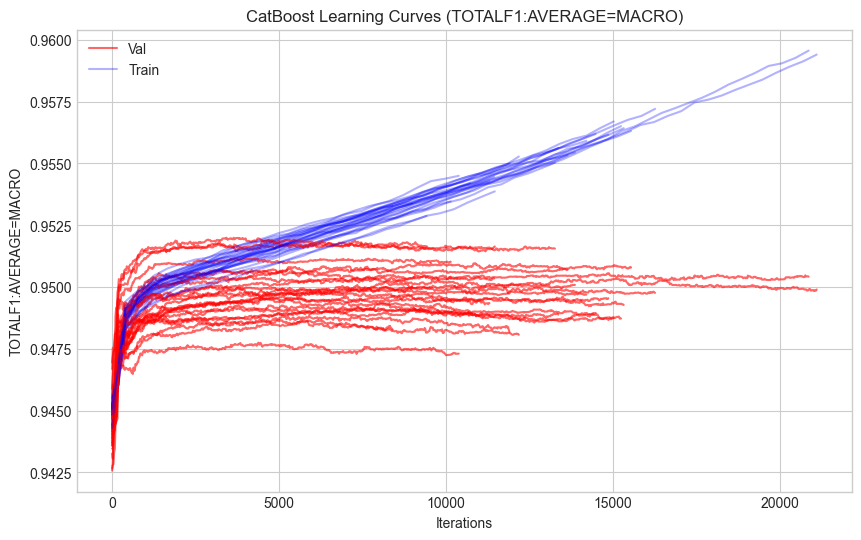

In [13]:
mviz = ModelVisualizer(model_name='CatBoost')

mviz.plot_learning_curves(eval_results, metric='TotalF1:average=Macro', metric_period=metric_period)

### Feature Importance
Average feature importance across folds.
* **Validation check:** lifestyle and body indicators like `bmi`, `sleep_duration`, `step_count`, `stress_level`, `exercise_duration` should dominate.
* **Feature check:** interaction features like `lifestyle_risk_score`, `sleep_quality_index`, and `calories_per_step` should rank highly if their corresponding strategies are active in `fe_strategies`.
* **Leakage check:** `id` must not appear in the chart at all.

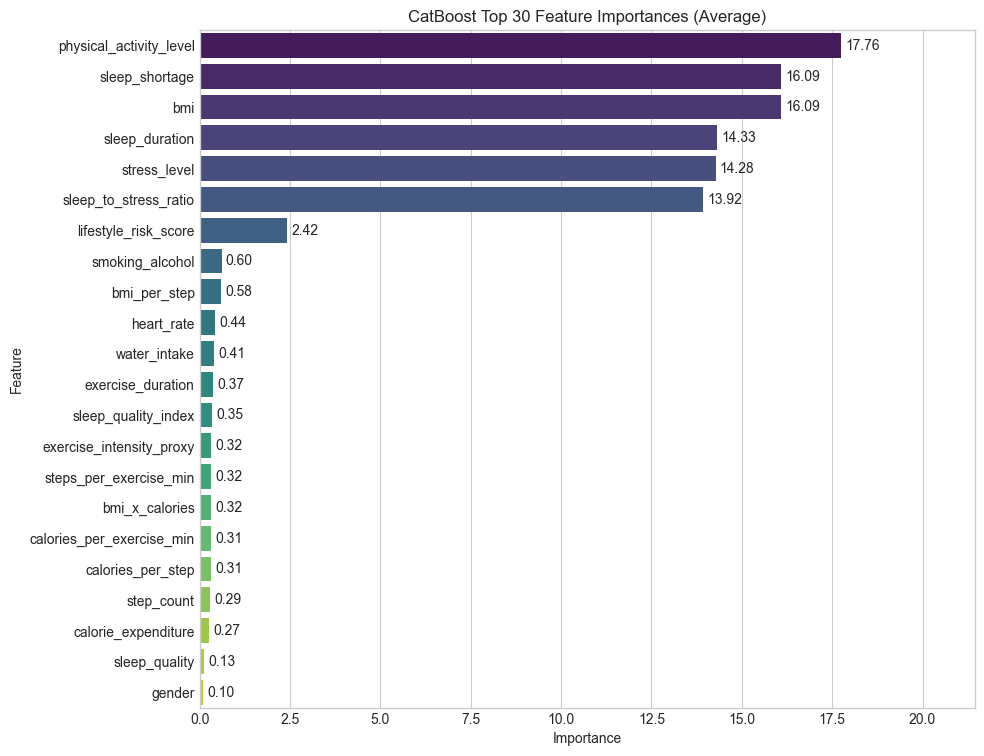

In [14]:
mviz.plot_feature_importance(models, show_values=True)

### Distribution Mismatch
Overlays the distribution of true class labels against OOF predicted labels (at-risk=0, unhealthy=1, fit=2). A large divergence on one class suggests the model is systematically misclassifying that stellar type.

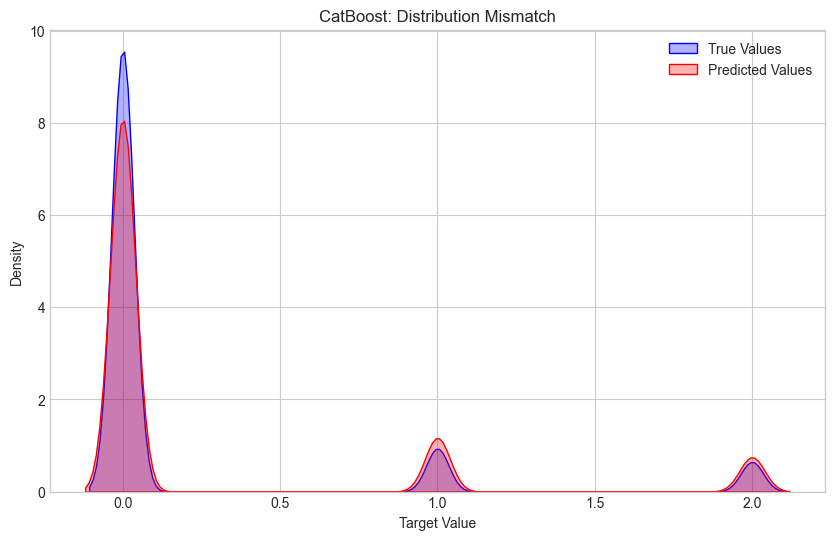

In [15]:
mviz.plot_distribution_mismatch(y_true=y[filled_mask], y_preds=oof_preds[filled_mask])

### Multiclass ROC Curve (One-vs-Rest)
Each class is treated as the positive class in turn. The AUC for each curve measures how well the model separates that class from the other two. All three curves should sit well above the diagonal; a sagging at-risk or unhealthy curve indicates a struggle to separate the specific risk levels.

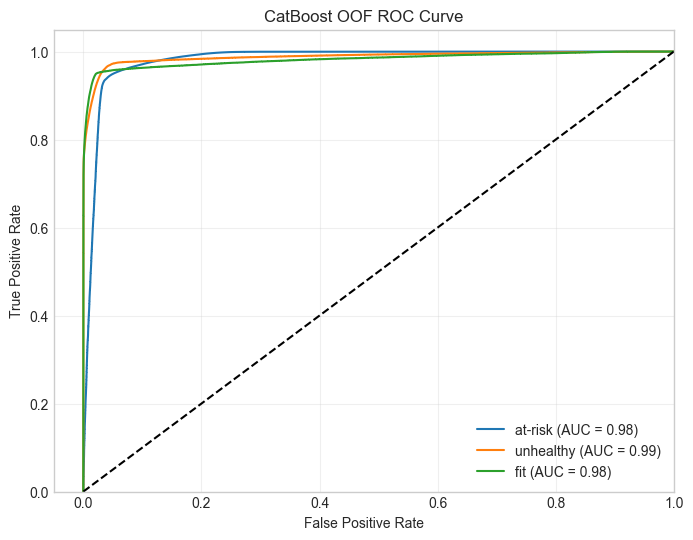

In [16]:
mviz.plot_multiclass_roc_curve(y_true=y[filled_mask], y_score=oof_probs[filled_mask], title='CatBoost OOF ROC Curve')

### Confusion Matrix (Out-of-Fold)
Shows which target health classes the model frequently confuses.
* **at-risk (0):** at-risk cases represent students with severe health risk behaviors; off-diagonal entries here are the most critical failures to monitor.
* **unhealthy (1):** unhealthy cases represent moderate risks; off-diagonal values between unhealthy and at-risk are common due to overlapping behavior metrics.
* **fit (2):** fit cases represent healthy behaviors; moderate confusion with unhealthy is expected as behaviors overlap.

Normalized confusion matrix


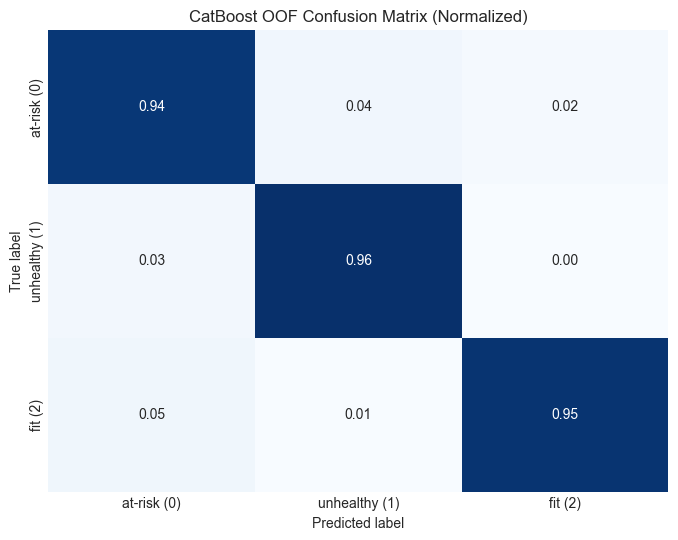

In [17]:
mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=oof_preds[filled_mask],
    classes=['at-risk (0)', 'unhealthy (1)', 'fit (2)'],
    normalize=True,
    title='CatBoost OOF Confusion Matrix (Normalized)'
)

## Prepare Submission

The competition requires the hard predicted class label (`at-risk`, `unhealthy`, or `fit`) for each row in the test set. We derive predictions by taking the argmax of the averaged test probabilities and mapping back to the original string labels.

In [18]:
submission_df = setup.read_dataset('submission')

numeric_preds = np.argmax(test_probs, axis=1)

# Map numeric predictions back to string class labels
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(numeric_preds).map(inverse_target_mapping)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))

SAMPLE SUBMISSION


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
5,690093,fit
6,690094,at-risk
7,690095,at-risk
8,690096,at-risk
9,690097,at-risk


In [19]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

OOF and averaged test-set probabilities are saved for downstream ensembling (blending or stacking).

For this three-class task we save the full probability distribution across `at-risk`, `unhealthy`, and `fit` rather than just the argmax labels. Raw probabilities are essential for:

- **Weighted Blending**: Averaging confidence scores across XGBoost, LightGBM, and CatBoost models.
- **Stacking**: Using these probabilities as meta-features for a secondary model.
- **Calibration Analysis**: Verifying that predicted confidence aligns with actual class frequencies.

In [20]:
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Column names match the class label mapping: at-risk=0, unhealthy=1, fit=2
prob_cols = ['prob_at_risk', 'prob_unhealthy', 'prob_fit']

# OOF probabilities — save only competition rows (original rows have no val prediction)
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)
oof_df = pd.concat([
    pd.DataFrame({'id': train_ids.values, 'target': y.values}),
    oof_prob_df
], axis=1)
oof_df = oof_df[filled_mask]  # drop original rows (their probs are all zeros)
oof_df.to_csv(f'{output_dir}/catboost_oof_probs.csv', index=False)

# Test probabilities
test_prob_df = pd.concat([
    pd.DataFrame({'id': test_ids.values}),
    pd.DataFrame(test_probs, columns=prob_cols)
], axis=1)
test_prob_df.to_csv(f'{output_dir}/catboost_test_probs.csv', index=False)

print(f'Saved for ensembling:\n - {output_dir}/catboost_oof_probs.csv\n - {output_dir}/catboost_test_probs.csv')

Saved for ensembling:
 - predictions/catboost_oof_probs.csv
 - predictions/catboost_test_probs.csv
